(114, 143) (114, 143)
Valid points: 15138


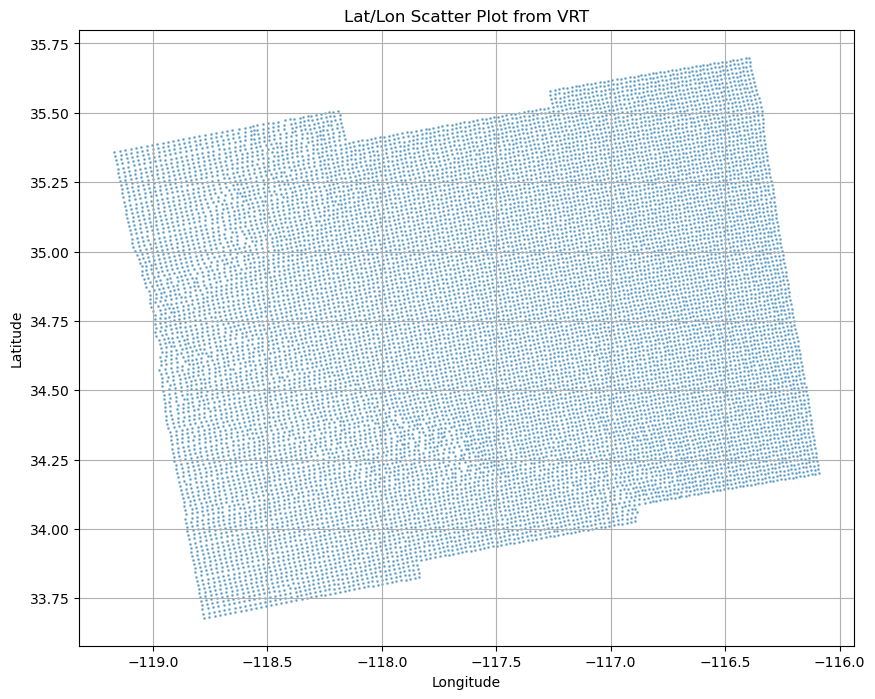

In [37]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

lat_vrt = "TA64_LA_Wildfires/geom_data/lat.rdr.16r4a.vrt"
lon_vrt = "TA64_LA_Wildfires/geom_data/lon.rdr.16r4a.vrt"

with rasterio.open(lat_vrt) as lat_ds, rasterio.open(lon_vrt) as lon_ds:
    lat = lat_ds.read(1)
    lon = lon_ds.read(1)

step=30

# 1) Subsample first (keeps spatial structure)
lat = lat[::step, ::step]
lon = lon[::step, ::step]


print(lat.shape, lon.shape)

mask = (
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat != 0) &
    (lon != 0) &
    (lat > 30) & (lat < 36) &
    (lon > -120) & (lon < -115)
)

lat_valid = lat[mask]
lon_valid = lon[mask]

print("Valid points:", lat_valid.size)

plt.figure(figsize=(10, 8))
plt.scatter(lon_valid, lat_valid, s=1, alpha=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Lat/Lon Scatter Plot from VRT")
plt.grid(True)

plt.show()



In [21]:
valid_mask = (
    np.isfinite(lat) &
    np.isfinite(lon) &
    (lat != 0) &
    (lon != 0)
)

lat_bad = (lat < 30) | (lat > 36)
lon_bad = (lon < -120) | (lon > -115)

# 3) Combine: only check valid pixels
bad_mask = valid_mask & (lat_bad | lon_bad)

bad_rc = np.argwhere(bad_mask)

print("Bad pixels:", bad_rc.shape[0])
print("First 5 (row, col):")
# print(bad_rc[:5])

# inspect values
for r, c in bad_rc[:200]:
    print(r, c, lat[r, c], lon[r, c])

Bad pixels: 4877
First 5 (row, col):
0 1348 16.915043751756585 -58.90798344203398
1 1348 16.915291328381826 -58.908037568848364
2 1348 16.915539274734545 -58.90808924431367
3 1348 16.9157885822764 -58.908131894408946
4 1348 16.916044051232713 -58.90813369151678
5 1348 16.916291934666376 -58.90818578364343
6 1348 16.916546265185715 -58.908195127690625
7 1348 16.916797613348777 -58.90822424600641
8 1348 16.917052943534866 -58.908226960003546
9 1348 16.917304814506533 -58.90825261053149
10 1348 16.917561639965317 -58.90824540771881
11 1348 16.917816865482664 -58.90824881281491
12 1348 16.918065789270607 -58.90829400429846
13 1348 16.918311789394096 -58.90835858288856
14 1348 16.918549678371498 -58.90847694767222
15 1348 16.918785005127592 -58.90861230325915
16 1348 16.919021952094127 -58.90873691550923
17 1348 16.919251043379152 -58.90891361975647
18 1348 16.919491313520954 -58.90901619670363
19 1348 16.91973502188286 -58.90909597498445
20 1348 16.919973665368058 -58.909209339344024
21 13

In [22]:
bad_rc.shape

(4877, 2)

In [23]:
lat.shape

(3393, 4272)

In [16]:
lat_valid.shape

(13540751,)